In [3]:
import gdown
import pandas as pd

#선 그래프로 추이 분석, 막대그래프, 그래프 색상, 이미지 생성 및 저장

gdown.download(r'https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

Downloading...
From: https://bit.ly/3pK7iuu
To: c:\data\ns_book7.csv
100%|██████████| 53.8M/53.8M [00:07<00:00, 6.89MB/s]


,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [4]:
#연도별 도서 개수 정리
count_by_year = ns_book7['발행년도'].value_counts().sort_index()
count_by_year = count_by_year[count_by_year.index <= 2030]
count_by_year

import numpy as np
 
#주제분류별 도서 개수 정리

def ex_num(no):
    if str(no).strip() == '':
        no = np.nan
    
    if pd.isna(no):
        return '-1'
    
    else:
        s = str(no)
        return s[0]

count_by_subject = ns_book7['주제분류번호'].apply(ex_num).value_counts().sort_values(ascending=False)
count_by_subject



주제분류번호
8     108643
3      80767
5      40916
9      26375
6      25070
1      22647
-1     16978
7      15836
4      13688
2      13474
0      12376
Name: count, dtype: int64

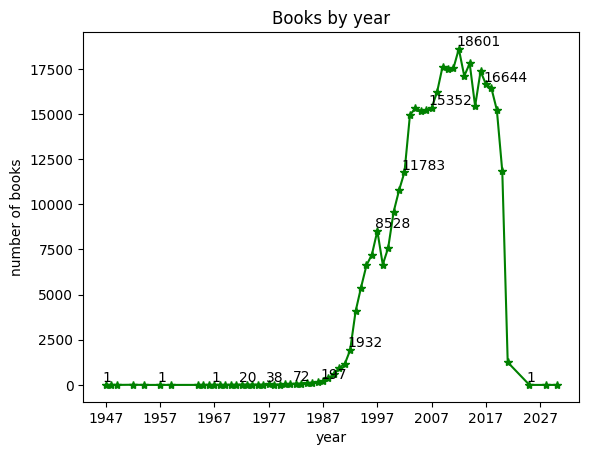

In [5]:
#발행연도별 도서개수 선 그래프 그리기 - 선 종류, 선 색깔, 마커포인트

import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

plt.plot(count_by_year, '*-g')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.xticks(range(1947, 2030, 10)) #ticks는 목록으로 전달!
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val), xytext=(-2, 2), textcoords='offset points')
plt.show()


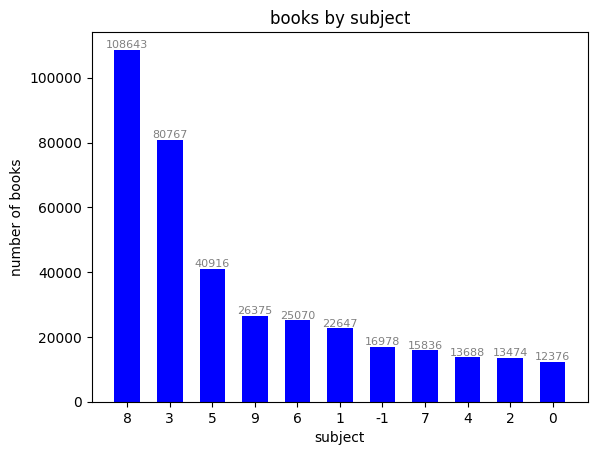

In [6]:
# 막대그래프 그리기. 
count_by_subject.sort_values(ascending=False, inplace=True)
plt.bar(count_by_subject.index, count_by_subject.values, width=0.6, color='blue')
plt.title('books by subject')
plt.xlabel('subject')
plt.ylabel('number of books')
for idx, val in count_by_subject.items():
    plt.annotate(val, (idx, val), xytext=(0, 2), textcoords='offset pixels',
                 ha='center', color='grey', fontsize=8)
plt.show()


(1561, 1646, 3)


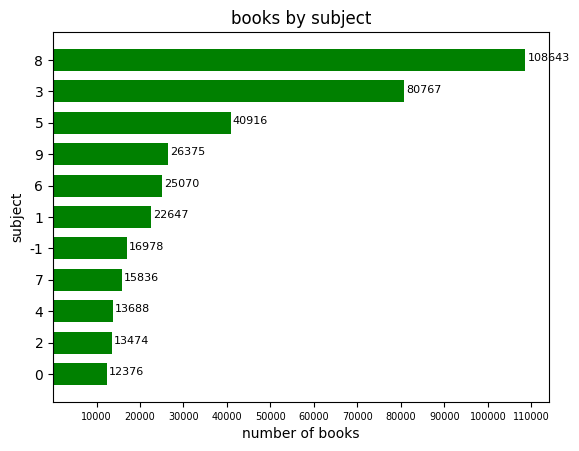

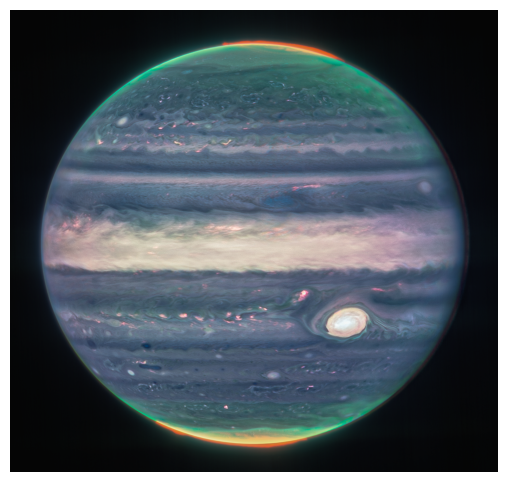

In [25]:
#가로형 막대그래프 그리기
count_by_subject.sort_values(ascending=True, inplace=True)
plt.barh(count_by_subject.index, count_by_subject.values, height=0.7, color='green') #bar horizontal
plt.title('books by subject')
plt.xlabel('number of books')
plt.ylabel('subject')
plt.xticks(range(10000, 120000, 10000), fontsize=7)
for idx, val in count_by_subject.items():
    plt.annotate(val, (val, idx), xytext=(2, 2), textcoords='offset pixels', va='center', fontsize=8, color='black')

plt.savefig('books_by_subject.png', dpi=240)

#이미지 출력/저장
import matplotlib.pyplot as plt
import requests

r = requests.get(r'https://bit.ly/3wrj4xf', timeout=10)
r.raise_for_status()

with open('jupiter.png', 'wb') as f:
    f.write(r.content)

img = plt.imread('jupiter.png') #이미지파일 읽기
print(img.shape) #이미지 파일 비율 규격 불러오기

plt.figure(figsize=(9, 6))
plt.axis('off') #축 제거
plt.imshow(img) #원본 파일 비율 그대로 읽기
plt.show() #출력




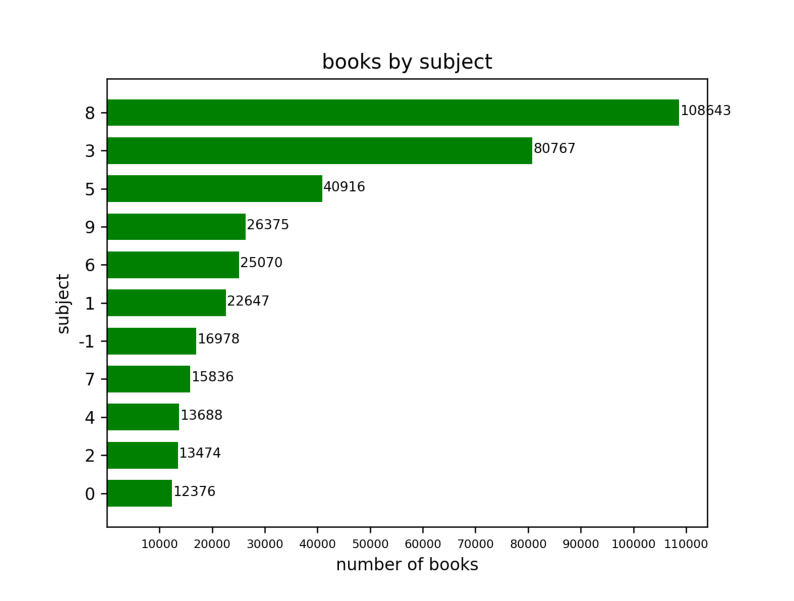

In [32]:
from PIL import Image

pil_img = plt.imread('books_by_subject.png')
plt.figure(figsize=(10, 10))
plt.imshow(pil_img)
plt.axis('off')
plt.show()